In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("dataset_2.csv")

In [13]:
df.head()

,Name,Trips Completed,Accept Rate,Supply Hours,Rating
0,Abdul,1,100%,3,4.8
1,Abraham,12,83%,5,4.7
2,Adelina,1,100%,2,4.7
3,Akilah,1,100%,2,4.9
4,Alec,21,76%,11,5.0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             119 non-null    str    
 1   Trips Completed  119 non-null    int64  
 2   Accept Rate      119 non-null    str    
 3   Supply Hours     119 non-null    int64  
 4   Rating           119 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.8 KB


In [15]:
df["Accept Rate"].describe

<bound method NDFrame.describe of 0      100%
1       83%
2      100%
3      100%
4       76%
       ... 
114    100%
115     71%
116     88%
117     78%
118     86%
Name: Accept Rate, Length: 119, dtype: str>

In [16]:
df["Accept Rate"] = df["Accept Rate"].str.strip("%").astype(float)

In [17]:
df["Accept Rate"].head()

0    100.0
1     83.0
2    100.0
3    100.0
4     76.0
Name: Accept Rate, dtype: float64

Scenario 1: It is going to be a huge Saturday and there will need to be many more cars on the road than last week. In order to get drivers to go online, we're assessing the following two bonus options in terms of cost:

Option 1: $50 for each driver that is online at least 8 hours, accepts 90% of requests, completes 10 trips, and has a rating of 4.7 or better during the time frame;

Option 2: $4/trip for all drivers who complete 12 trips, and have a 4.7 or better rating.

Using the dataset provided and given Scenario 1, provide answers to the questions below:

#### 1. How much would the total bonus payout be with Option 1?
#### 2. How much would the total bonus payout be with Option 2?
#### 3. How many drivers would qualify for a bonus under Option 1 but not under Option 2?
#### 4. What percentages of drivers online completed less than 10 trips, had an acceptance rate of less than 90%, and had a rating of 4.7 or higher?

### Senario 1

### Option 1

In [20]:
option1 = df[
    (df["Accept Rate"]>=90.0) & 
    (df["Supply Hours"]>=8) & 
    (df["Trips Completed"]>=10) & 
    (df["Rating"]>= 4.7)
    ]

In [21]:
option1.head()

,Name,Trips Completed,Accept Rate,Supply Hours,Rating
11,Byron,15,100.0,10,4.9
12,Carlota,14,100.0,8,5.0
19,Dannette,14,100.0,9,4.9
23,Demetrius,14,100.0,9,5.0
26,Dimple,15,100.0,10,4.9


In [28]:
total_pay_op1 = len(option1) * 50

In [29]:
print(total_pay_op1)

1050


### Option 2

In [30]:
option2 = df[
    (df["Trips Completed"]>=12) &
    (df["Rating"]>= 4.7)
]

In [33]:
total_pay_op2 = (option2["Trips Completed"] *4).sum()

In [34]:
print(total_pay_op2)

2976


In [40]:
opt1Notopt2 = option1[~option1["Name"].isin(option2["Name"])]

In [60]:
print(f"There are {len(opt1Notopt2)} drivers in Option one but not under Option two")

There are 2 drivers in Option one but not under Option two


In [48]:
lessThan10Trips = (df["Trips Completed"] < 10).sum() / len(df) * 100.0
bellow90 = (df["Accept Rate"] < 90.0).sum() / len(df) * 100.0
rating_over = (df["Rating"] >= 4.7).sum() / len(df) * 100.0

In [53]:
print(f"Less than 10 trips: {lessThan10Trips:.2f}%")
print(f"Acceptance rate less than 90%: {bellow90:.2f}%")
print(f"Rating 4.7 or more: {rating_over:.2f}%")

Less than 10 trips: 33.61%
Acceptance rate less than 90%: 46.22%
Rating 4.7 or more: 68.91%


In [54]:
print("=" * 40)
print("SCENARIO 1 RESULTS")
print("=" * 40)
print(f"Option 1 total payout:       ${total_pay_op1:,}")
print(f"Option 2 total payout:       ${total_pay_op2:,}")
print(f"In Option 1 but not Option 2: {len(opt1Notopt2)} drivers")
print("-" * 40)
print(f"Less than 10 trips:          {lessThan10Trips:.2f}%")
print(f"Acceptance rate < 90%:       {bellow90:.2f}%")
print(f"Rating >= 4.7:               {rating_over:.2f}%")

SCENARIO 1 RESULTS
Option 1 total payout:       $1,050
Option 2 total payout:       $2,976
In Option 1 but not Option 2: 2 drivers
----------------------------------------
Less than 10 trips:          33.61%
Acceptance rate < 90%:       46.22%
Rating >= 4.7:               68.91%


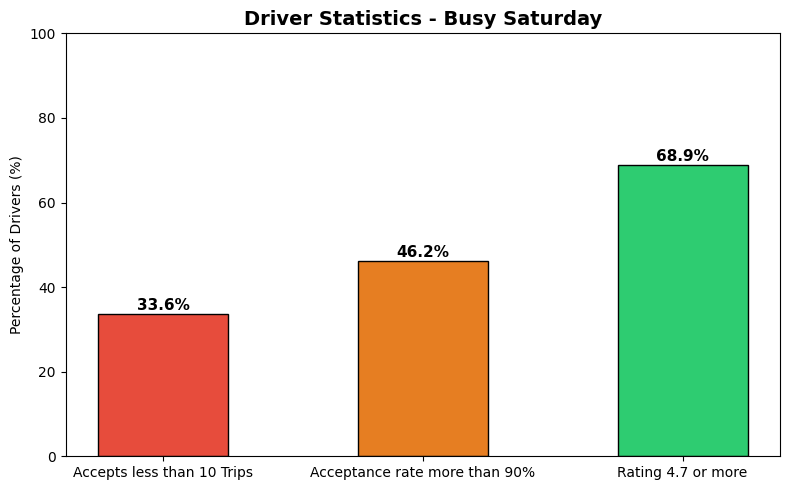

In [58]:
labels = ['Accepts less than 10 Trips', 'Acceptance rate more than 90%', 'Rating 4.7 or more']
values = [lessThan10Trips, bellow90, rating_over]
colors = ['#e74c3c', '#e67e22', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.title('Driver Statistics - Busy Saturday', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Drivers (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Scenario 2: A taxi driver currently generates $200 per day in fares (before expenses), works six days a week, takes three weeks off, and has the following expenses:

Gas - $200 per week 

Insurance - $400 per month 

Vehicle rent (by the week) - $500

The driver doesn't pay gas and rent expenses on off weeks.

Now, let's assume that the same driver would buy a Town Car and partner with Uber. If he does, his gas expenses would go up by 5%, his insurance expense would decrease by 20%, and he would no longer be renting a vehicle. However, he would need to buy a car. The driver would still take three weeks off per year.

Given Scenario 2, provide answers to the questions below:

#### 5. How much money (after expenses) does the taxi driver make per year without partnering with Uber?
#### 6. You are convincing the same driver above to buy a Town Car and partner with Uber. Assuming the new car is 40,000 USD, how much would the driver's gross fares need to increase per week to fully pay for the car in year 1 and maintain the same yearly profit margin as before?

In [61]:
Revenue = (200 * 6) * 49

In [73]:
Gas = 49 * 200
Insurance = 12 * 400
Vehicle_rent = 49 * 500
total_expense = Gas + Insurance + Vehicle_rent
total_expense

39100

In [ ]:
withoutUber = Revenue - total_expense
print(f"A taxi driver make {withoutUber}$ a year without uber.")

A taxi driver make 19700$ a year without uber


In [76]:
uber_gas = ((200 * .05) + 200) * 49
uber_insurance = ((400 * -(.2)) + 400) * 12
car_cost = 40000
profit_target = 19700
total_expense_uber_expense = uber_gas + uber_insurance + 40000
print(total_expense_uber_expense)

54130.0


In [77]:
required_revenue = profit_target + total_expense_uber_expense

In [83]:
extra_weekly_fare = (required_revenue- Revenue)/ 49
print(f"The same driver needs make {extra_weekly_fare: .2f}$ weekly to pay the full car price in one year and maintain the same profit he used to do without uber")

The same driver needs make  306.73$ weekly to pay the full car price in one year and maintain the same profit he used to do without uber
